# 0. 한영 번역기 만들기

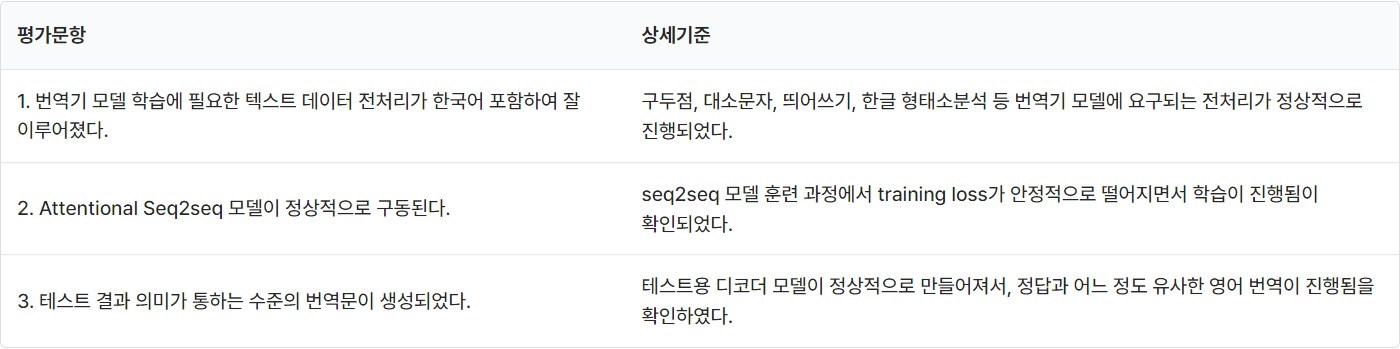

어텐션을 이용해 한영 번역기를 만들어보자...

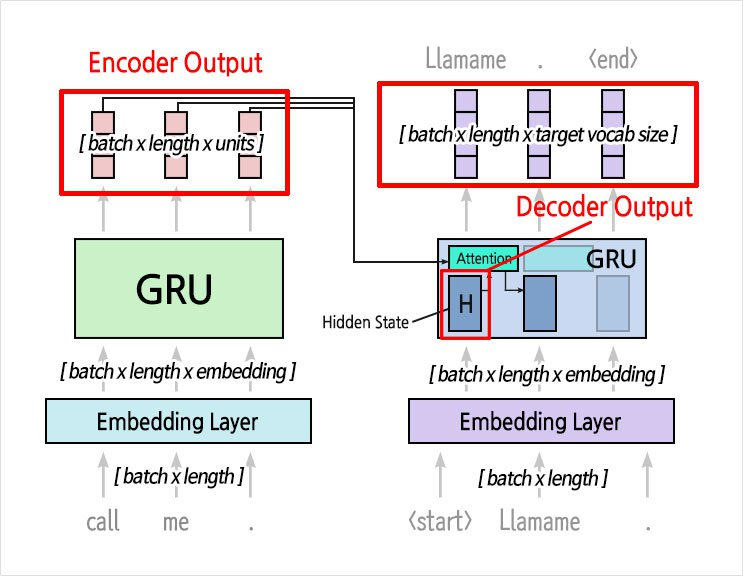

In [16]:
corpus_df = pd.DataFrame(zip(kor_corpus, eng_corpus),
                         columns=['Korean', 'English'])

In [17]:
corpus_df

,Korean,English
0,바락 대변인 은 영화 섹스 앤 더 시티 의 옥외 광고 를 담당 하 는 이스라엘 광고...,<start> the israeli company that is handling o...
1,빌 리처드슨 뉴멕시코 주지사 는 2 일 현지 시간 빌 클린턴 이 리처드슨 주지사 가...,<start> new mexico gov . bill richardson on we...
2,크로포드 박사 는 새해 결심 을 성공 하 는 4 가지 방법 을 제안 했 다 .,<start> he offered four tips for succeeding . ...
3,이 들 을 태운 영국 항공 비행기 가 런던 에 도착 한 4 일 현지 시간 토니 블레...,<start> speaking in downing street as the brit...
4,미국 으로 이송 돼 민간 형사 법정 에서 재판 을 받 는 첫 사례 가 되 는 그 는...,<start> the detainee was indicted by a federal...
...,...,...
78963,이 는 아메리칸 대학 의 정치 학자 인 앨런 리치만 의 말 이 었 으며 전미 도시 ...,<start> political scientist allan lichtman of ...
78964,이 로써 두 아르테 대통령 은 의회 가 조기 사임 을 결정 하 지 않 는 한 공식 ...,<start> that means duarte must continue as pre...
78965,하워드 올프 손 힐러리 선거 캠프 대변인 은 그 들 오바마 캠프 은 연이 은 패배 ...,<start> they can try to spin a 6 point loss in...
78966,인도양 지역 의 출생 인 노랑 거북복 ostracion cubicus 은 보 기 보...,"<start> a native of the indo pacific region , ..."


In [18]:
# point
min_len = 2
max_len = 40

In [19]:
OLD_LEN = len(corpus_df)

print('기존 샘플 수:', OLD_LEN)

corpus_df = corpus_df[corpus_df.apply(
    lambda x: (min_len <= len(x[0].split()) <= max_len)
    and (min_len+2 <= len(x[1].split()) <= max_len+2), axis=1)] # point

print('전체 샘플 수 :', len(corpus_df))
print('제거된 샘플 수:', OLD_LEN - len(corpus_df))

기존 샘플 수: 78968
전체 샘플 수 : 62037
제거된 샘플 수: 16931


In [20]:
kor_corpus = corpus_df['Korean'].to_list()
eng_corpus = corpus_df['English'].to_list()

문장의 최단 길이: 2
문장의 최장 길이: 40
문장의 중위 길이: 26.0


/tmp/ipykernel_545/4135604288.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  sentence_length = np.zeros((max(sen_lens)), dtype=np.int)


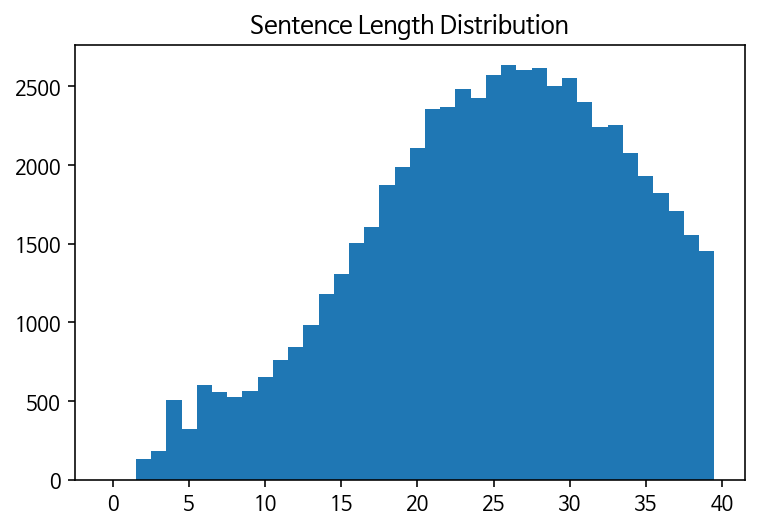

In [21]:
cal_sentence_length(kor_corpus)

문장의 최단 길이: 4
문장의 최장 길이: 42
문장의 중위 길이: 23.0


/tmp/ipykernel_545/4135604288.py:8: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  sentence_length = np.zeros((max(sen_lens)), dtype=np.int)


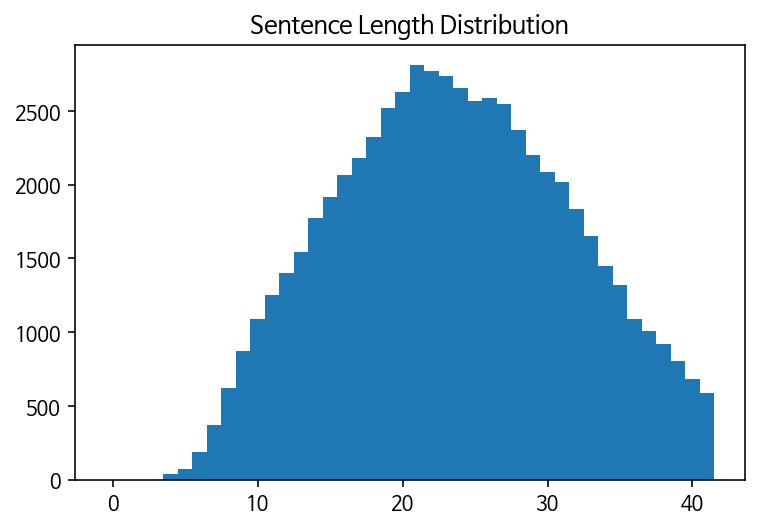

In [22]:
cal_sentence_length(eng_corpus)

# 3. 데이터 토큰화

In [23]:
def tokenize(corpus, num_words):
    tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=num_words, filters='')
    tokenizer.fit_on_texts(corpus)

    tensor = tokenizer.texts_to_sequences(corpus)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')

    return tensor, tokenizer

In [24]:
# 토큰화하기
NUM_WORDS = 10000 # point
enc_tensor, enc_tokenizer = tokenize(kor_corpus, NUM_WORDS)
dec_tensor, dec_tokenizer = tokenize(eng_corpus, NUM_WORDS)

In [25]:
def tsize(train_X):
    length = len(train_X)
    return round(0.14 * (1 + length / 10 ** 4) ** (10 ** 4 / length) - 0.13, 2)

In [26]:
tsize(enc_tensor)

0.06

In [27]:
# 훈련 데이터와 검증 데이터로 분리하기
enc_train, enc_val, dec_train, dec_val = \
train_test_split(enc_tensor, dec_tensor, test_size=tsize(enc_tensor))

print("Korean Vocab Size:", len(enc_tokenizer.index_word))
print("English Vocab Size:", len(dec_tokenizer.index_word))

Korean Vocab Size: 45065
English Vocab Size: 39721


# 4. 모델 설계

한국어를 영어로 잘 번역해 줄 멋진 Attention 기반 Seq2seq 모델을 설계하자.

In [28]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.w_enc = tf.keras.layers.Dense(units)
        self.w_dec = tf.keras.layers.Dense(units)
        self.w_com = tf.keras.layers.Dense(1)
    
    def call(self, h_enc, h_dec):
        # h_enc shape: [batch x length x units]
        # h_dec shape: [batch x units]
        h_enc = self.w_enc(h_enc)
        h_dec = tf.expand_dims(h_dec, 1)
        h_dec = self.w_dec(h_dec)
        score = self.w_com(tf.nn.tanh(h_dec + h_enc))
        attn = tf.nn.softmax(score, axis=1)
        context_vec = attn * h_enc
        context_vec = tf.reduce_sum(context_vec, axis=1)

        return context_vec, attn

In [29]:
# point
class Encoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, enc_units):
        super(Encoder, self).__init__()
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.lnorm = tf.keras.layers.LayerNormalization()
        self.gru = tf.keras.layers.GRU(enc_units, return_sequences=True)
        self.drop = tf.keras.layers.Dropout(0.5)
        
    def call(self, x):
        out = self.embedding(x)
        out = self.lnorm(out)
        out = self.gru(out)
        out = self.drop(out)
        
        return out

In [30]:
# point
class Decoder(tf.keras.Model):
    def __init__(self, vocab_size, embedding_dim, dec_units):
        super(Decoder, self).__init__()
        self.attention = BahdanauAttention(dec_units)
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.lnorm = tf.keras.layers.LayerNormalization()
        self.gru = tf.keras.layers.GRU(dec_units, return_sequences=True,
                                       return_state=True)
        self.drop = tf.keras.layers.Dropout(0.5)
        self.fc = tf.keras.layers.Dense(vocab_size)

    def call(self, x, h_dec, enc_out):
        context_vec, attn = self.attention(enc_out, h_dec)
        out = self.embedding(x)
        out = tf.concat([tf.expand_dims(context_vec, 1), out], axis=-1)
        out = self.lnorm(out)
        out, h_dec = self.gru(out)
        out = self.drop(out)
        out = tf.reshape(out, (-1, out.shape[2]))
        out = self.fc(out)

        return out, h_dec, attn

In [31]:
SRC_VOCAB_SIZE = NUM_WORDS + 1
TGT_VOCAB_SIZE = NUM_WORDS + 1

EMBEDDING_DIM = 2 ** 7 # point
UNITS         = 2 ** 9 # point
BATCH_SIZE    = 2 ** 5 # point

encoder = Encoder(SRC_VOCAB_SIZE, EMBEDDING_DIM, UNITS)
decoder = Decoder(TGT_VOCAB_SIZE, EMBEDDING_DIM, UNITS)

# sample input
SEQUENCE_LEN = 40

sample_enc = tf.random.uniform((BATCH_SIZE, SEQUENCE_LEN))
sample_output = encoder(sample_enc)

sample_state = tf.random.uniform((BATCH_SIZE, UNITS))

sample_logits, h_dec, attn = decoder(tf.random.uniform((BATCH_SIZE, 1)),
                                     sample_state, sample_output)

print ('Encoder Input:', sample_enc.shape)
print ('Encoder Output:', sample_output.shape)

print ('Decoder Input:', sample_state.shape)
print ('Decoder Output:', sample_logits.shape)
print ('Decoder Hidden State:', h_dec.shape)
print ('Attention:', attn.shape)

Encoder Input: (32, 40)
Encoder Output: (32, 40, 512)
Decoder Input: (32, 512)
Decoder Output: (32, 10001)
Decoder Hidden State: (32, 512)
Attention: (32, 40, 1)


# 5. 훈련하기

## 5.1. Optimizer & Loss

In [32]:
optimizer = tf.keras.optimizers.Adam()

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

In [33]:
def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss = loss_object(real, pred)
    
    mask = tf.cast(mask, dtype=loss.dtype)
    loss *= mask
    
    return tf.reduce_mean(loss)

## 5.2. train_step 구현하기

In [34]:
@tf.function
def train_step(src, tgt, encoder, decoder, optimizer, dec_tok):
    bsz = src.shape[0]
    loss = 0

    with tf.GradientTape() as tape:
        enc_out = encoder(src)
        h_dec = enc_out[:, -1]
        
        dec_src = tf.expand_dims([dec_tok.word_index['<start>']] * bsz, 1)

        for t in range(1, tgt.shape[1]):
            pred, h_dec, _ = decoder(dec_src, h_dec, enc_out)

            loss += loss_function(tgt[:, t], pred)
            dec_src = tf.expand_dims(tgt[:, t], 1)
        
    batch_loss = (loss / int(tgt.shape[1]))

    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))
    
    return batch_loss

In [35]:
# Define eval_step
@tf.function
def eval_step(src, tgt, encoder, decoder, dec_tok):
    bsz = src.shape[0]
    loss = 0

    enc_out = encoder(src)

    h_dec = enc_out[:, -1]
    
    dec_src = tf.expand_dims([dec_tok.word_index['<start>']] * bsz, 1)

    for t in range(1, tgt.shape[1]):
        pred, h_dec, _ = decoder(dec_src, h_dec, enc_out)

        loss += loss_function(tgt[:, t], pred)
        dec_src = tf.expand_dims(tgt[:, t], 1)
        
    batch_loss = (loss / int(tgt.shape[1]))
    
    return batch_loss

## 5.3. 훈련 시작하기

In [36]:
# Training Process

EPOCHS = 6 # point

for epoch in range(EPOCHS):
    total_loss = 0
    
    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (batch, idx) in enumerate(t):
        batch_loss = train_step(enc_train[idx:idx+BATCH_SIZE],
                                dec_train[idx:idx+BATCH_SIZE],
                                encoder,
                                decoder,
                                optimizer,
                                dec_tokenizer)
    
        total_loss += batch_loss
        
        t.set_description_str('Epoch %2d' % (epoch + 1))
        t.set_postfix_str('Loss %.4f' % (total_loss.numpy() / (batch + 1)))
    
    test_loss = 0
    
    idx_list = list(range(0, enc_val.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for (test_batch, idx) in enumerate(t):
        test_batch_loss = eval_step(enc_val[idx:idx+BATCH_SIZE],
                                    dec_val[idx:idx+BATCH_SIZE],
                                    encoder,
                                    decoder,
                                    dec_tokenizer)
    
        test_loss += test_batch_loss

        t.set_description_str('Test Epoch %2d' % (epoch + 1))
        t.set_postfix_str('Test Loss %.4f' % (test_loss.numpy() / (test_batch + 1)))

Test Epoch  6: 100%|██████████| 117/117 [00:05<00:00, 23.20it/s, Test Loss 2.2309]


In [37]:
def evaluate(sentence, encoder, decoder):
    attention = np.zeros((dec_train.shape[-1], enc_train.shape[-1]))
    
    sentence = preprocess_sentence(sentence)
    inputs = enc_tokenizer.texts_to_sequences([sentence.split()])
    inputs = tf.keras.preprocessing.sequence.pad_sequences(inputs,
                                                           maxlen=enc_train.shape[-1],
                                                           padding='post')

    result = ''

    enc_out = encoder(inputs)

    dec_hidden = enc_out[:, -1]
    dec_input = tf.expand_dims([dec_tokenizer.word_index['<start>']], 0)

    for t in range(dec_train.shape[-1]):
        predictions, dec_hidden, attention_weights = decoder(dec_input,
                                                             dec_hidden,
                                                             enc_out)

        attention_weights = tf.reshape(attention_weights, (-1, ))
        attention[t] = attention_weights.numpy()

        predicted_id = \
        tf.argmax(tf.math.softmax(predictions, axis=-1)[0]).numpy()

        result += dec_tokenizer.index_word[predicted_id] + ' '

        if dec_tokenizer.index_word[predicted_id] == '<end>':
            return result, sentence, attention

        dec_input = tf.expand_dims([predicted_id], 0)

    return result, sentence, attention


In [38]:
def plot_attention(attention, sentence, predicted_sentence):
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(1, 1, 1)
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
    ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

In [39]:
def translate(sentence, encoder, decoder):
    result, sentence, attention = evaluate(sentence, encoder, decoder)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))
    
    attention = attention[:len(result.split()), :len(sentence.split())]
    plot_attention(attention, sentence.split(), result.split(' '))

/tmp/ipykernel_545/421837482.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_545/421837482.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


Input: 오바마는 대통령이다 .
Predicted translation: they are a . <end> 


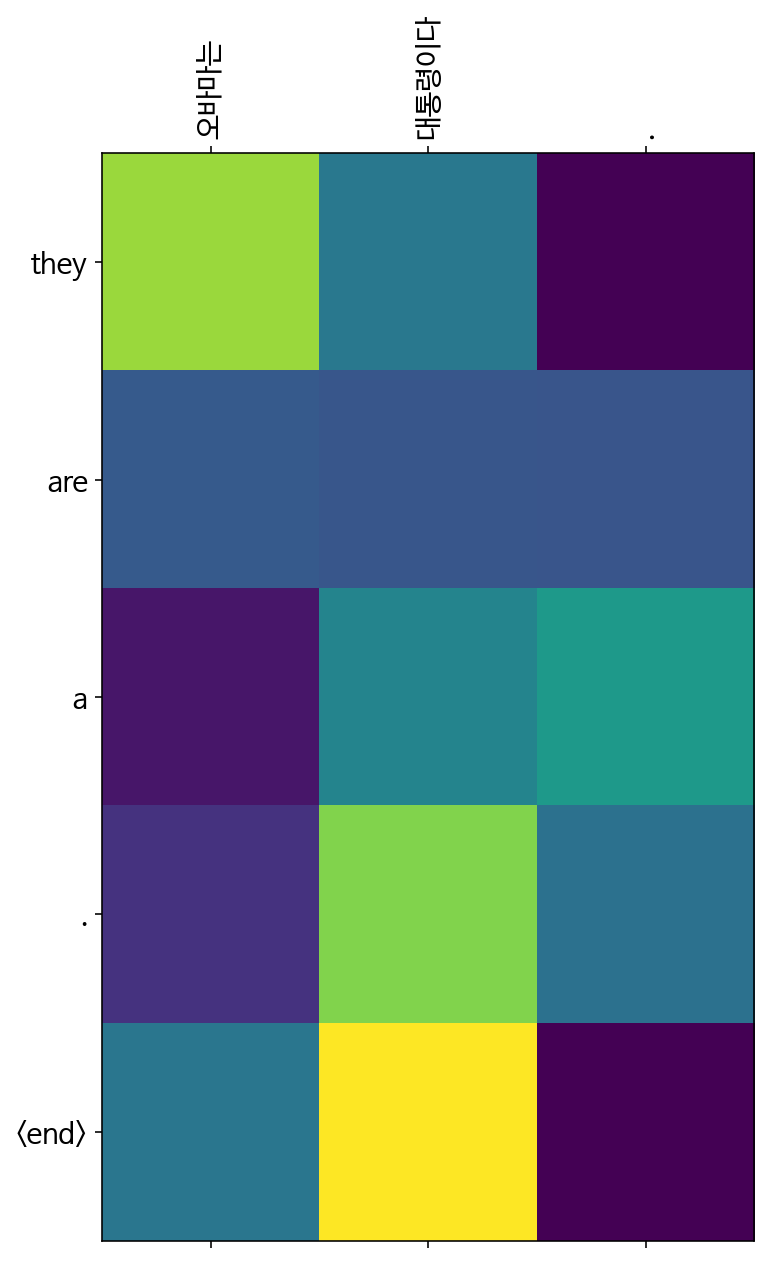

In [40]:
translate("오바마는 대통령이다.", encoder, decoder)

Input: 시민들은 도시 속에 산다 .
Predicted translation: city . <end> 


/tmp/ipykernel_545/421837482.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_545/421837482.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


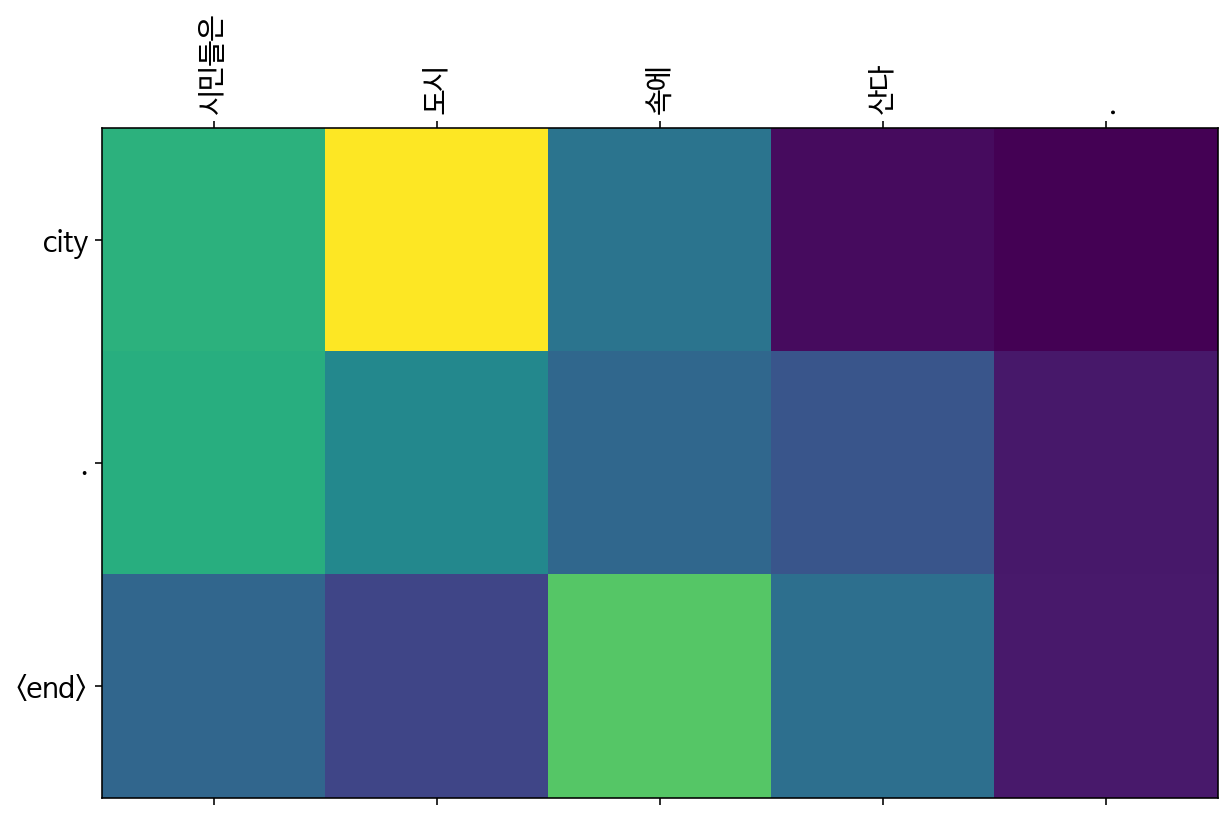

In [41]:
translate("시민들은 도시 속에 산다.", encoder, decoder)

Input: 커피는 필요 없다 .
Predicted translation: we do not be a little . <end> 


/tmp/ipykernel_545/421837482.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_545/421837482.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


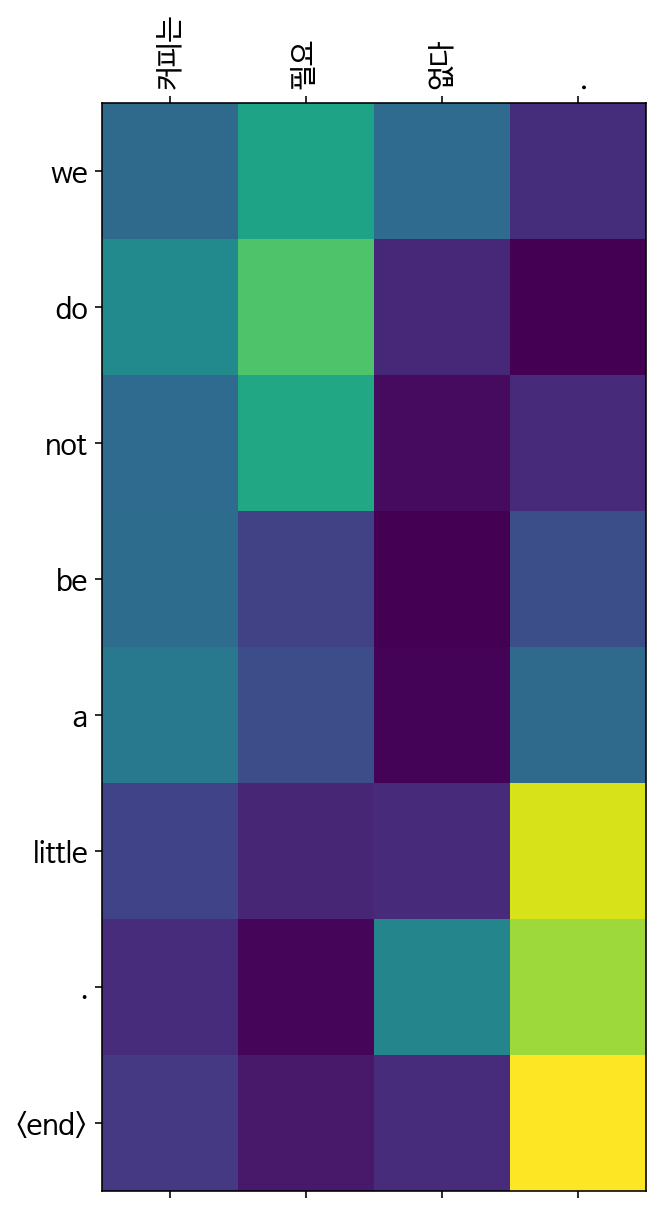

In [42]:
translate("커피는 필요 없다.", encoder, decoder)

Input: 일곱 명의 사망자가 발생했다 .
Predicted translation: the seven year old man . <end> 


/tmp/ipykernel_545/421837482.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] + sentence, fontdict=fontdict, rotation=90)
/tmp/ipykernel_545/421837482.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] + predicted_sentence, fontdict=fontdict)


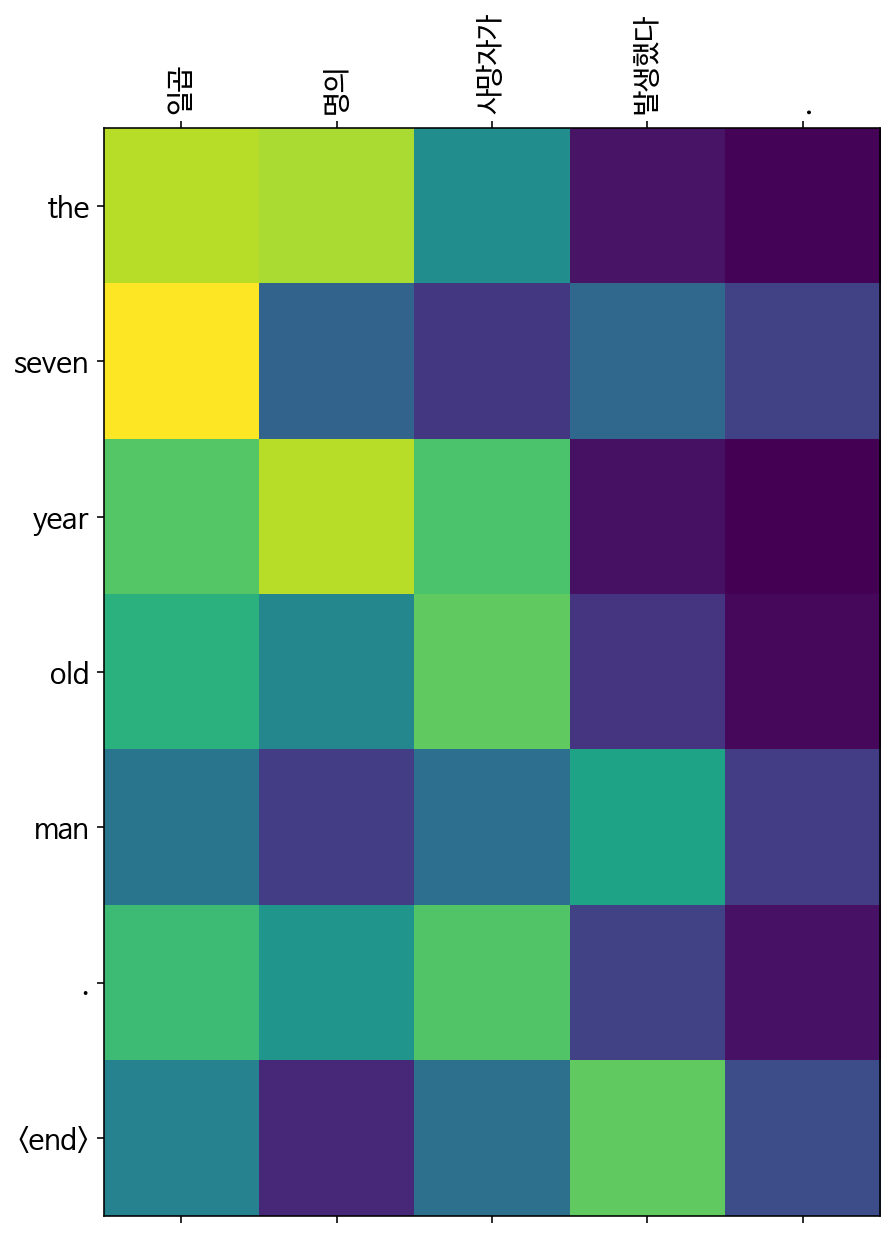

In [43]:
translate("일곱 명의 사망자가 발생했다.", encoder, decoder)

# 6. 회고하기

마크다운을 한 파일을 실수로 삭제해버렸다. 의욕이 사라져 버렸다.

하이퍼 퍼래머더를 아무리 변경해도 성능이 만족스럽지 않았다.  

전처리쪽 문제 같지만 엄두가 나지 않았다.  

다음에는 전처리에 신경을 써야될 것 같다.